In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("data/SampleSuperstore.csv")

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [5]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.duplicated().sum()

np.int64(17)

In [ ]:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB

In [7]:
df.drop_duplicates(inplace=true)

NameError: name 'true' is not defined

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print("Total Sales: ${:,.2f}".format(df["Sales"].sum()))
print("Total Profit: ${:,.2f}".format(df["Profit"].sum()))
print("Average Sales per Order: ${:,.2f}".format(df["Sales"].mean()))
print("Average Profit per Order: ${:,.2f}".format(df["Profit"].mean()))

Total Sales: $2,296,195.59
Total Profit: $286,241.42
Average Sales per Order: $230.15
Average Profit per Order: $28.69


In [10]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64

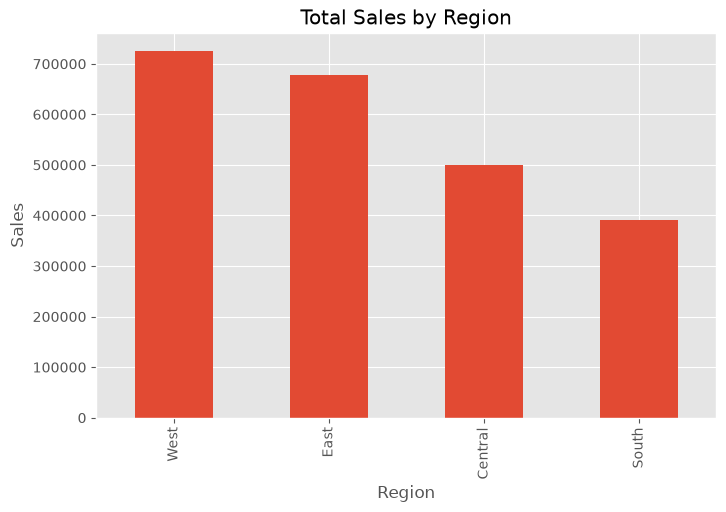

In [11]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()


As per the records and graph, it is clear that the West region has outperformed everyone in total sales. The company should investigate the factors behind it and if possible, look into whether similar methods can help in enhancing the performance of regions lagging behind.

In [15]:
region_profit= df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_profit


Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64

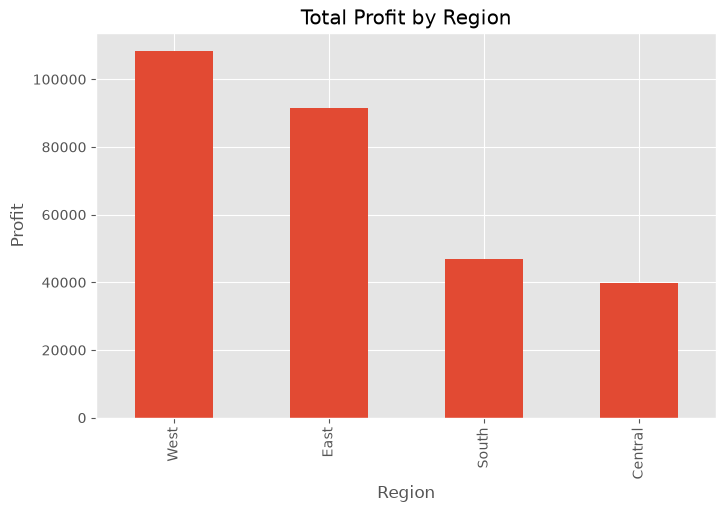

In [17]:
region_profit.plot(kind="bar", figsize=(8,5))

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()


Although the West region has the highest profit, some regions with relatively high sales contribute much less to profitability. This indicates differences in operational efficiency, discounting strategies, or product mix.

In [18]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


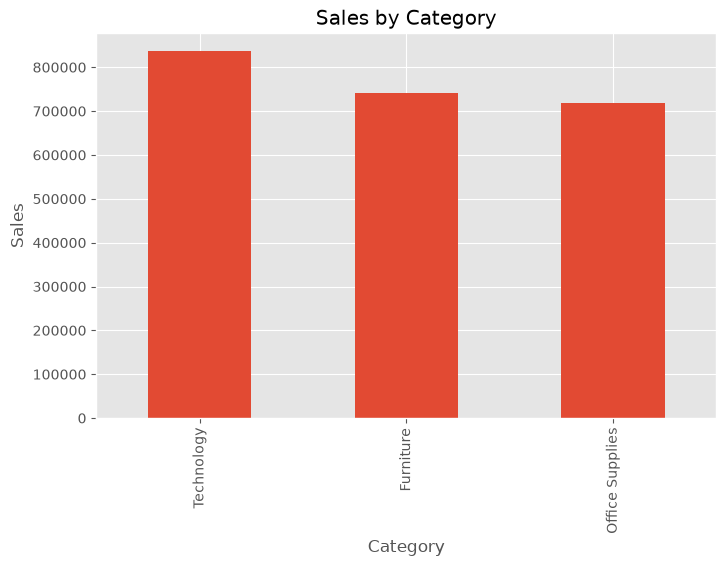

In [19]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Technology contributes the highest sales among all categories, indicating strong customer demand. This category may deserve additional investment in inventory and marketing.


In [20]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


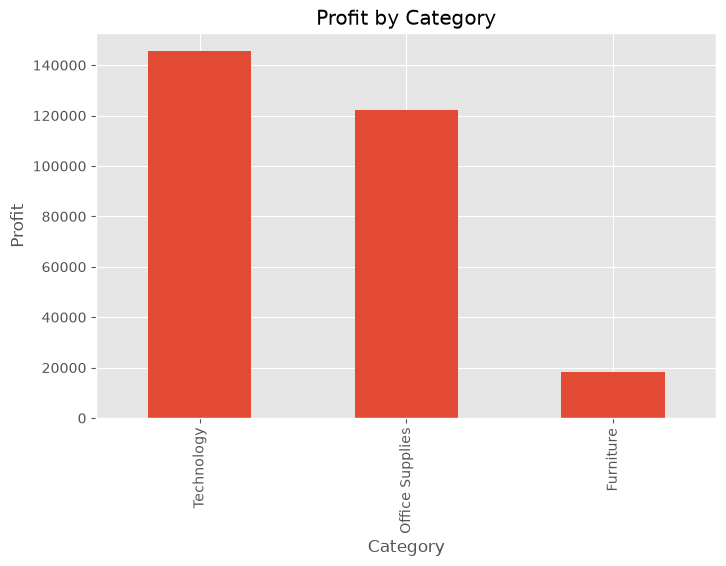

In [21]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

Although Furniture and Office supplies have comparable sales, the profits earned by Office Supplies outweigh that of Furniture. Office supplies section may be given higher priority and the Furniture section's inablity to procure profits should be looked at.

In [22]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

print(subcategory_profit)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Storage        21278.8264
Chairs         26567.1278
Binders        30228.0003
Paper          33944.2395
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


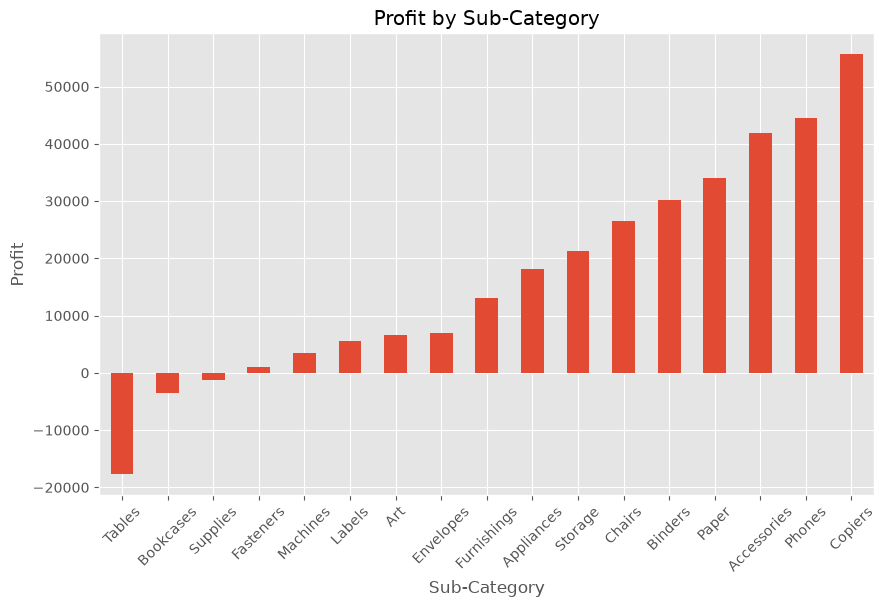

In [23]:
plt.figure(figsize=(10,6))

subcategory_profit.plot(kind='bar')

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

Some sub-categories, especially belonging to Furniture category generate negative profits despite contributing to sales. These products require further investigation regarding pricing, discounts, or supply chain costs.

In [24]:
furniture_profit = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(furniture_profit)

Sub-Category
Chairs         26567.1278
Furnishings    13052.7230
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


In furniture category, Bookcases and Tables are generating negative profits

In [25]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

top10 = state_sales.head(10)

print(top10)

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


In [28]:
top5_states = (
    df.groupby(["Region", "State"])["Profit"]
    .sum()
    .groupby(level=0)
    .nlargest(5)
)

print(top5_states)

Region   Region   State       
Central  Central  Michigan        24428.0903
                  Indiana         18382.9363
                  Minnesota       10823.1874
                  Wisconsin        8401.8004
                  Missouri         6436.2105
East     East     New York        74015.4622
                  Delaware         9977.3748
                  New Jersey       9772.9138
                  Rhode Island     7285.6293
                  Maryland         7031.1788
South    South    Virginia        18597.9504
                  Georgia         16250.0433
                  Kentucky        11199.6966
                  Alabama          5786.8253
                  Arkansas         4008.6871
West     West     California      76330.7891
                  Washington      33368.2375
                  Nevada           3316.7659
                  Utah             2546.5335
                  Montana          1833.3285
Name: Profit, dtype: float64


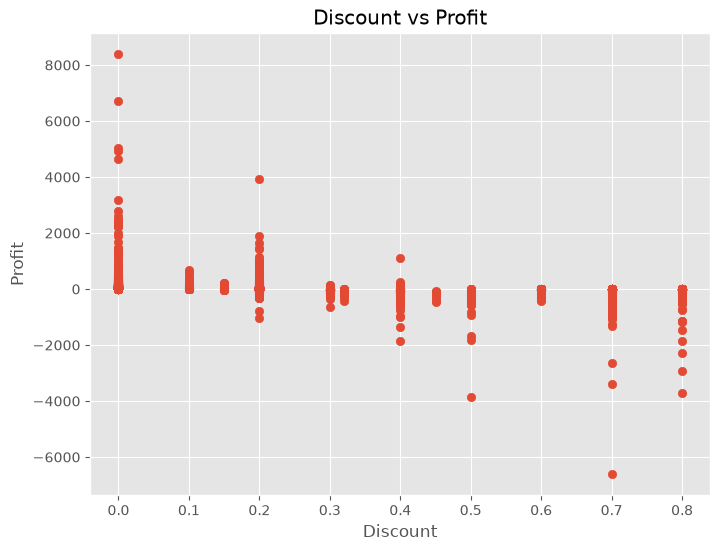

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Higher discounts are generally associated with lower profitability. While discounts may increase sales volume, excessive discounting can significantly reduce profit margins. The company should evaluate its discount strategy to balance revenue growth with profitability.

In [32]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

print(city_sales)

City
New York City    256319.0410
Los Angeles      175831.9010
Seattle          119460.2820
San Francisco    112577.1720
Philadelphia     109061.4610
Houston           64441.2564
Chicago           48535.9770
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


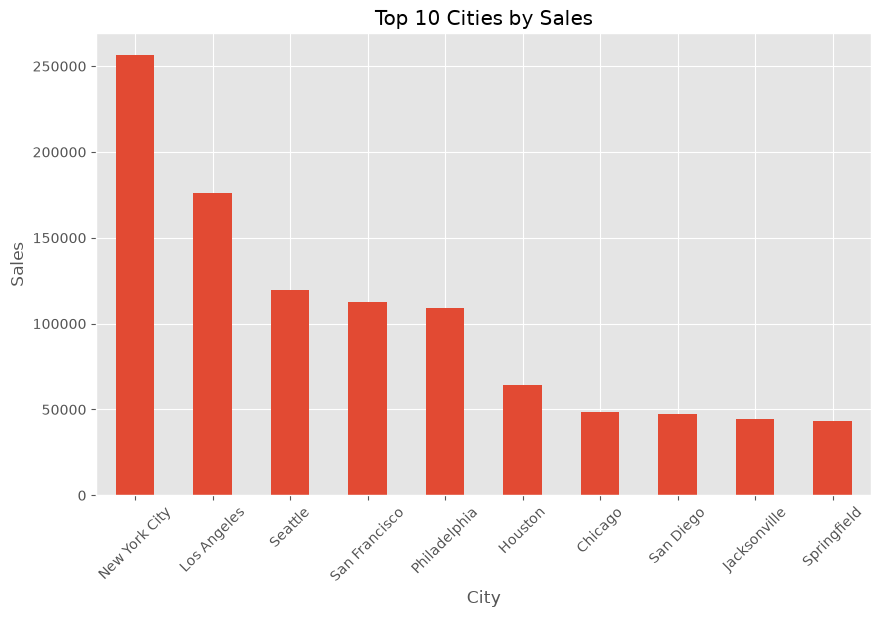

In [36]:
plt.figure(figsize=(10,6))

city_sales.plot(kind='bar')

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

The top 10 cities by sales

# Executive Summary

This project analyzes retail sales data containing 9,994 customer transactions across different regions, states, product categories, and customer segments.

The objective of the analysis is to identify sales trends, profitability drivers, customer behavior, and opportunities for business improvement using Python and data visualization.

The analysis focuses on answering key business questions related to regional performance, product profitability, discount strategies, and customer contribution.

# Key Findings

• The West region generated the highest overall sales and profit.

• Technology was the highest-performing category in terms of revenue.

• Certain furniture sub-categories such as Tables and Bookcases generated low or negative profits despite good sales.

• California and New York contributed significantly to overall sales.

• Several products consistently generated losses and require further investigation.

• Higher discounts were generally associated with lower profitability.

• A relatively small group of customers contributed a disproportionately high share of total profit.

# Business Recommendations

1. Review the discount policy to prevent excessive profit loss.

2. Focus marketing efforts on high-performing regions while identifying reasons behind weaker regional performance.

3. Re-evaluate pricing and inventory strategies for consistently loss-making products.

4. Increase investment in high-profit product categories.

5. Develop customer retention strategies for high-value customers through loyalty programs and personalized offers.

6. Continuously monitor profitability instead of focusing solely on sales volume.

# Future Scope

This analysis can be further enhanced by:

• Building an interactive Power BI dashboard.

• Developing predictive models to forecast future sales.

• Performing customer segmentation using clustering techniques.

• Conducting time-series analysis if order dates become available.

• Creating automated reporting pipelines for business users.